# Version 4 : RSF Optimisé Final

**Configuration optimale issue de V3.1** :
- ✅ **90 features sélectionnées** (basées sur importance)
- ✅ **Hyperparamètres optimaux** (trouvés par grid search V3.1)

**Objectif** : Entraîner le modèle final avec la meilleure configuration connue

**Hyperparamètres** :
- n_estimators: 350
- min_samples_split: 27
- min_samples_leaf: 5
- max_features: 0.2
- max_depth: 23
- bootstrap: True

## 1. Setup

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sksurv.ensemble import RandomSurvivalForest
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Libraries imported")

✓ Libraries imported


## 2. Configuration Optimale

In [10]:
# Best 90 features (from V3.1)
BEST_FEATURES = [
    'BM_BLAST', 'HB', 'PLT', 'vaf_sum', 'mutation_count_total', 'effect_non_synonymous_codon',
    'gene_RUNX1_count', 'WBC', 'cyto_total_anomalies', 'gene_RUNX1_present', 'ANC', 'cyto_normal',
    'MONOCYTES', 'vaf_mean', 'gene_TP53_count', 'cyto_complex', 'gene_TP53_present', 'cyto_loss_count',
    'effect_frameshift_variant', 'gene_NRAS_present', 'gene_NRAS_count', 'CENTER_PV', 'effect_PTD',
    'gene_ASXL1_count', 'cyto_chr7_affected', 'gene_TET2_count', 'gene_SF3B1_present', 'vaf_max',
    'gene_DNMT3A_present', 'gene_U2AF1_present', 'gene_SF3B1_count', 'CENTER_RMCN', 'cyto_chr18_affected',
    'cyto_gain_count', 'gene_U2AF1_count', 'cyto_chr1_affected', 'cyto_chrX_affected', 'cyto_other_count',
    'cyto_transloc_count', 'cyto_chr3_affected', 'gene_NF1_count', 'cyto_chr7_abnormal', 'gene_EZH2_present',
    'cyto_chr6_affected', 'CENTER_TUD', 'gene_SRSF2_count', 'gene_DNMT3A_count', 'gene_PHF6_count',
    'gene_TET2_present', 'CENTER_ROM', 'effect_inframe_codon_gain', 'gene_BCOR_count', 'CENTER_GESMD',
    'gene_CUX1_present', 'cyto_chr4_affected', 'gene_ZRSR2_count', 'gene_ZRSR2_present', 'CENTER_DUS',
    'cyto_chrY_affected', 'CENTER_CGM', 'cyto_del5q', 'cyto_chr15_affected', 'cyto_chr14_affected',
    'gene_NF1_present', 'CENTER_DUTH', 'CENTER_HIAE', 'effect_complex_change_in_transcript',
    'effect_initiator_codon_change', 'cyto_chr3_abnormal', 'cyto_chr19_affected', 'cyto_chr10_affected',
    'CENTER_UMG', 'CENTER_REL', 'CENTER_IHBT', 'CENTER_HMS', 'CENTER_MSK', 'effect_3_prime_UTR_variant',
    'effect_2KB_upstream_variant', 'effect_ITD', 'effect_stop_lost', 'cyto_inv_count',
    'effect_stop_retained_variant', 'effect_inframe_variant', 'effect_synonymous_codon', 'CENTER_VU',
    'CENTER_UOXF', 'CENTER_UOB', 'gene_KRAS_present', 'gene_KRAS_count', 'cyto_has_inv'
]

# Best hyperparameters (from V3.1 optimization)
BEST_PARAMS = {
    'n_estimators': 350,
    'min_samples_split': 27,
    'min_samples_leaf': 5,
    'max_features': 0.2,
    'max_depth': 23,
    'bootstrap': True,
    'n_jobs': -1,
    'random_state': 42,
    'verbose': 1
}

print(f"✓ Configuration loaded")
print(f"  Features: {len(BEST_FEATURES)}")
print(f"  Hyperparameters: {len(BEST_PARAMS)}")

✓ Configuration loaded
  Features: 90
  Hyperparameters: 9


## 3. Data Loading

In [11]:
DATA_PATH = r"C:\Users\guill\Desktop\Data Challenge QRT\Data-Challenge-Prediction-de-Survie"

clinical_train = pd.read_csv(f"{DATA_PATH}\\X_train\\clinical_train.csv")
target_train = pd.read_csv(f"{DATA_PATH}\\target_train.csv")
clinical_test = pd.read_csv(f"{DATA_PATH}\\X_test\\clinical_test.csv")
molecular_train = pd.read_csv(f"{DATA_PATH}\\X_train\\molecular_train.csv")
molecular_test = pd.read_csv(f"{DATA_PATH}\\X_test\\molecular_test.csv")

print(f"✓ Data loaded: {clinical_train.shape[0]} train patients")

✓ Data loaded: 3323 train patients


## 4. Feature Engineering

Créer toutes les features (132) puis sélectionner les 90 meilleures

In [12]:
def create_cytogenetic_features(clinical_df):
    """Create cytogenetic features"""
    cyto_features = pd.DataFrame(index=clinical_df['ID'])
    cyto_col = clinical_df.set_index('ID')['CYTOGENETICS'].fillna('')
    
    # Anomaly types
    cyto_features['cyto_del_count'] = cyto_col.str.count(r'del\(')
    cyto_features['cyto_has_del'] = (cyto_features['cyto_del_count'] > 0).astype(int)
    cyto_features['cyto_transloc_count'] = cyto_col.str.count(r't\(')
    cyto_features['cyto_has_transloc'] = (cyto_features['cyto_transloc_count'] > 0).astype(int)
    cyto_features['cyto_inv_count'] = cyto_col.str.count(r'inv\(')
    cyto_features['cyto_has_inv'] = (cyto_features['cyto_inv_count'] > 0).astype(int)
    cyto_features['cyto_gain_count'] = cyto_col.str.count(r'\+')
    cyto_features['cyto_has_gain'] = (cyto_features['cyto_gain_count'] > 0).astype(int)
    cyto_features['cyto_loss_count'] = cyto_col.str.count(r'-[0-9XY]')
    cyto_features['cyto_has_loss'] = (cyto_features['cyto_loss_count'] > 0).astype(int)
    cyto_features['cyto_other_count'] = cyto_col.str.count(r'add\(|ins\(|dup\(')
    
    # Complexity
    cyto_features['cyto_total_anomalies'] = (
        cyto_features['cyto_del_count'] + cyto_features['cyto_transloc_count'] + 
        cyto_features['cyto_inv_count'] + cyto_features['cyto_gain_count'] + 
        cyto_features['cyto_loss_count'] + cyto_features['cyto_other_count']
    )
    cyto_features['cyto_normal'] = cyto_col.str.match(r'^46,(xx|xy)(\[\d+\])?$', case=False).astype(int)
    cyto_features['cyto_complex'] = (
        (cyto_features['cyto_total_anomalies'] >= 3) | 
        cyto_col.str.contains('complex', case=False, na=False)
    ).astype(int)
    
    # Chromosomes
    chromosomes = [str(i) for i in range(1, 23)] + ['X', 'Y']
    for chrom in chromosomes:
        pattern = rf'(\b|[,\(]){chrom}([,;:\)\[]|[pq])'
        cyto_features[f'cyto_chr{chrom}_affected'] = cyto_col.str.contains(
            pattern, case=False, na=False, regex=True
        ).astype(int)
    
    # Prognostic markers
    cyto_features['cyto_monosomy7'] = cyto_col.str.contains(r'-7[^0-9]|^45.*-7', case=False, na=False, regex=True).astype(int)
    cyto_features['cyto_trisomy8'] = cyto_col.str.contains(r'\+8[^0-9]|^47.*\+8', case=False, na=False, regex=True).astype(int)
    cyto_features['cyto_del5q'] = cyto_col.str.contains(r'del\(5\)\(q', case=False, na=False, regex=True).astype(int)
    cyto_features['cyto_del20q'] = cyto_col.str.contains(r'del\(20\)\(q', case=False, na=False, regex=True).astype(int)
    cyto_features['cyto_chr3_abnormal'] = cyto_col.str.contains(r'(del|t|inv)\(3[;,:\)]', case=False, na=False, regex=True).astype(int)
    cyto_features['cyto_chr7_abnormal'] = cyto_col.str.contains(r'(del|t|inv)\(7[;,:\)]', case=False, na=False, regex=True).astype(int)
    
    return cyto_features.fillna(0)

def create_molecular_features(molecular_df, patient_ids, top_n_genes=20):
    """Create molecular features"""
    mol_features = pd.DataFrame({'ID': patient_ids})
    
    mutation_counts = molecular_df.groupby('ID').size().to_frame('mutation_count_total')
    mol_features = mol_features.merge(mutation_counts, on='ID', how='left')
    
    vaf_stats = molecular_df.groupby('ID')['VAF'].agg([
        ('vaf_mean', 'mean'), ('vaf_max', 'max'), ('vaf_sum', 'sum')
    ]).reset_index()
    mol_features = mol_features.merge(vaf_stats, on='ID', how='left')
    
    effect_counts = molecular_df.groupby(['ID', 'EFFECT']).size().unstack(fill_value=0)
    effect_counts.columns = [f'effect_{col}' for col in effect_counts.columns]
    mol_features = mol_features.merge(effect_counts.reset_index(), on='ID', how='left')
    
    top_genes_list = molecular_df['GENE'].value_counts().head(top_n_genes).index.tolist()
    for gene in top_genes_list:
        gene_mutations = molecular_df[molecular_df['GENE'] == gene].groupby('ID').size()
        mol_features[f'gene_{gene}_count'] = mol_features['ID'].map(gene_mutations)
        gene_present = molecular_df[molecular_df['GENE'] == gene]['ID'].unique()
        mol_features[f'gene_{gene}_present'] = mol_features['ID'].isin(gene_present).astype(int)
    
    feature_cols = [col for col in mol_features.columns if col != 'ID']
    mol_features[feature_cols] = mol_features[feature_cols].fillna(0)
    return mol_features.set_index('ID')

print("✓ Feature engineering functions defined")

✓ Feature engineering functions defined


In [13]:
# Create all features
cyto_features_train = create_cytogenetic_features(clinical_train)
train_patient_ids = clinical_train['ID'].unique()
mol_features_train = create_molecular_features(molecular_train, train_patient_ids, top_n_genes=20)

# Clean target
target_clean = target_train.dropna(subset=['OS_YEARS', 'OS_STATUS']).copy()
target_clean['OS_STATUS'] = target_clean['OS_STATUS'].astype(bool)
target_clean = target_clean.set_index('ID')

# Clinical features
clinical_train_clean = clinical_train[clinical_train['ID'].isin(target_clean.index)].copy()
clinical_train_clean = clinical_train_clean.set_index('ID').loc[target_clean.index]

numeric_features = ['BM_BLAST', 'WBC', 'ANC', 'MONOCYTES', 'HB', 'PLT']
X_numeric = clinical_train_clean[numeric_features].copy()
center_encoded = pd.get_dummies(clinical_train_clean['CENTER'], prefix='CENTER', drop_first=True)
X_clinical = pd.concat([X_numeric, center_encoded], axis=1)

# Combine all
mol_features_train_aligned = mol_features_train.reindex(X_clinical.index, fill_value=0)
cyto_features_train_aligned = cyto_features_train.reindex(X_clinical.index, fill_value=0)
X_all = pd.concat([X_clinical, mol_features_train_aligned, cyto_features_train_aligned], axis=1)

print(f"✓ All features created: {X_all.shape[1]}")

✓ All features created: 132


## 5. Feature Selection (Top 90)

In [14]:
# Select only the 90 best features
available_features = [f for f in BEST_FEATURES if f in X_all.columns]
missing_features = [f for f in BEST_FEATURES if f not in X_all.columns]

print(f"Available features: {len(available_features)}/{len(BEST_FEATURES)}")
if missing_features:
    print(f"\nWarning: {len(missing_features)} features not found:")
    for f in missing_features[:5]:
        print(f"  - {f}")
    if len(missing_features) > 5:
        print(f"  ... and {len(missing_features)-5} more")

X_selected = X_all[available_features].copy()
print(f"\n✓ Selected features: {X_selected.shape[1]}")

Available features: 90/90

✓ Selected features: 90


In [15]:
# Imputation
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X_selected),
    index=X_selected.index,
    columns=X_selected.columns
)

# Create survival target
y_surv = Surv.from_dataframe('OS_STATUS', 'OS_YEARS', target_clean)

print(f"✓ Data prepared: {X_imputed.shape}")
print(f"✓ Events: {y_surv['OS_STATUS'].sum()} / {len(y_surv)}")

✓ Data prepared: (3173, 90)
✓ Events: 1600 / 3173


## 6. Train/Val Split

In [16]:
X_train, X_val, y_train, y_val = train_test_split(
    X_imputed, y_surv, test_size=0.3, random_state=42,
    stratify=target_clean['OS_STATUS'].astype(int)
)

print(f"Train: {X_train.shape[0]} patients")
print(f"Val: {X_val.shape[0]} patients")

Train: 2221 patients
Val: 952 patients


## 7. Model Training (Optimal Config)

In [17]:
print("="*60)
print("TRAINING RSF WITH OPTIMAL CONFIGURATION")
print("="*60)
print(f"\nFeatures: {X_train.shape[1]}")
print("\nHyperparameters:")
for param, value in BEST_PARAMS.items():
    if param not in ['n_jobs', 'random_state', 'verbose']:
        print(f"  {param}: {value}")

rsf = RandomSurvivalForest(**BEST_PARAMS)
print("\n🌲 Training...")
rsf.fit(X_train, y_train)
print("\n✓ Model trained successfully")

TRAINING RSF WITH OPTIMAL CONFIGURATION

Features: 90

Hyperparameters:
  n_estimators: 350
  min_samples_split: 27
  min_samples_leaf: 5
  max_features: 0.2
  max_depth: 23
  bootstrap: True

🌲 Training...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.6s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    4.1s



✓ Model trained successfully


[Parallel(n_jobs=-1)]: Done 350 out of 350 | elapsed:   10.4s finished


## 8. Evaluation

In [18]:
# Predictions
y_pred_train = rsf.predict(X_train)
y_pred_val = rsf.predict(X_val)

# C-index
c_index_train = concordance_index_censored(
    y_train['OS_STATUS'], y_train['OS_YEARS'], y_pred_train
)[0]

c_index_val = concordance_index_censored(
    y_val['OS_STATUS'], y_val['OS_YEARS'], y_pred_val
)[0]

print("="*60)
print("MODEL PERFORMANCE")
print("="*60)
print(f"Train C-index: {c_index_train:.4f}")
print(f"Val C-index: {c_index_val:.4f}")
print(f"Overfitting: {c_index_train - c_index_val:.4f}")

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.5s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    3.7s
[Parallel(n_jobs=12)]: Done 350 out of 350 | elapsed:    7.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.1s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    1.2s


MODEL PERFORMANCE
Train C-index: 0.8251
Val C-index: 0.7404
Overfitting: 0.0847


[Parallel(n_jobs=12)]: Done 350 out of 350 | elapsed:    2.3s finished


## 9. Comparison with Previous Versions

In [19]:
comparison_df = pd.DataFrame([
    {'Version': 'V2', 'Features': 88, 'C-index': 0.7334, 'Notes': 'Clinical + Molecular'},
    {'Version': 'V3', 'Features': 132, 'C-index': 0.7320, 'Notes': '+ Cytogenetic (all)'},
    {'Version': 'V3.1', 'Features': 90, 'C-index': 'TBD', 'Notes': 'Grid search optimized'},
    {'Version': 'V4', 'Features': len(available_features), 'C-index': c_index_val, 'Notes': 'Final optimal config'}
])

print("\n" + "="*60)
print("VERSION COMPARISON")
print("="*60)
print(comparison_df.to_string(index=False))

if c_index_val >= 0.7334:
    improvement = (c_index_val - 0.7334) * 100
    print(f"\n✓ Improvement vs V2: {improvement:+.2f}%")


VERSION COMPARISON
Version  Features   C-index                 Notes
     V2        88    0.7334  Clinical + Molecular
     V3       132     0.732   + Cytogenetic (all)
   V3.1        90       TBD Grid search optimized
     V4        90  0.740434  Final optimal config

✓ Improvement vs V2: +0.70%


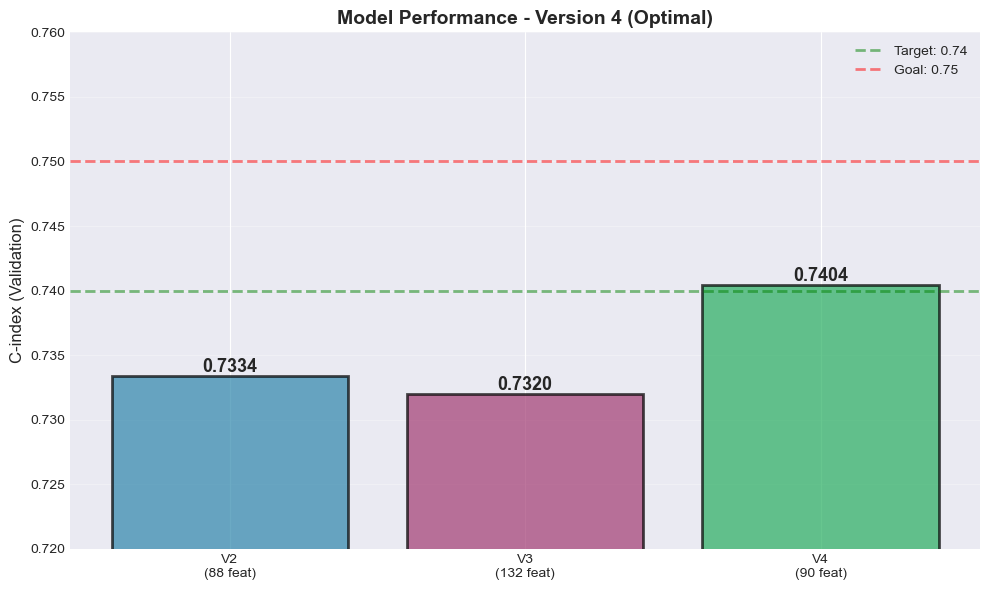

In [20]:
# Visualization
fig, ax = plt.subplots(figsize=(10, 6))

versions = ['V2\n(88 feat)', 'V3\n(132 feat)', f'V4\n({len(available_features)} feat)']
scores = [0.7334, 0.7320, c_index_val]
colors = ['#2E86AB', '#A23B72', '#27AE60']

bars = ax.bar(versions, scores, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

for bar, score in zip(bars, scores):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{score:.4f}',
            ha='center', va='bottom', fontsize=13, fontweight='bold')

ax.axhline(y=0.74, color='green', linestyle='--', linewidth=2, alpha=0.5, label='Target: 0.74')
ax.axhline(y=0.75, color='red', linestyle='--', linewidth=2, alpha=0.5, label='Goal: 0.75')

ax.set_ylabel('C-index (Validation)', fontsize=12)
ax.set_title('Model Performance - Version 4 (Optimal)', fontsize=14, fontweight='bold')
ax.set_ylim([0.72, max(0.76, c_index_val + 0.01)])
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 10. Test Set Preparation

In [22]:
print("="*60)
print("PREPARING TEST SET")
print("="*60)

# Create features for test
cyto_features_test = create_cytogenetic_features(clinical_test)
test_patient_ids = clinical_test['ID'].unique()
mol_features_test = create_molecular_features(molecular_test, test_patient_ids, top_n_genes=20)

# Clinical features
clinical_test_indexed = clinical_test.set_index('ID')
X_numeric_test = clinical_test_indexed[numeric_features].copy()
center_encoded_test = pd.get_dummies(clinical_test_indexed['CENTER'], prefix='CENTER', drop_first=True)
for col in center_encoded.columns:
    if col not in center_encoded_test.columns:
        center_encoded_test[col] = 0
center_encoded_test = center_encoded_test[center_encoded.columns]
X_clinical_test = pd.concat([X_numeric_test, center_encoded_test], axis=1)

# Combine
mol_features_test_aligned = mol_features_test.reindex(X_clinical_test.index, fill_value=0)
cyto_features_test_aligned = cyto_features_test.reindex(X_clinical_test.index, fill_value=0)
X_test_all = pd.concat([X_clinical_test, mol_features_test_aligned, cyto_features_test_aligned], axis=1)

# Add missing features with zeros (for features not in test set)
for feature in available_features:
    if feature not in X_test_all.columns:
        X_test_all[feature] = 0
        print(f"  Added missing feature: {feature}")

# Select same features
X_test_selected = X_test_all[available_features].copy()

# Impute
X_test_imputed = pd.DataFrame(
    imputer.transform(X_test_selected),
    index=X_test_selected.index,
    columns=X_test_selected.columns
)

print(f"✓ Test set prepared: {X_test_imputed.shape}")

PREPARING TEST SET
  Added missing feature: gene_NF1_count
  Added missing feature: gene_PHF6_count
  Added missing feature: gene_CUX1_present
  Added missing feature: gene_ZRSR2_count
  Added missing feature: gene_ZRSR2_present
  Added missing feature: gene_NF1_present
  Added missing feature: effect_complex_change_in_transcript
  Added missing feature: effect_initiator_codon_change
  Added missing feature: effect_3_prime_UTR_variant
  Added missing feature: effect_2KB_upstream_variant
  Added missing feature: effect_stop_retained_variant
  Added missing feature: effect_inframe_variant
  Added missing feature: effect_synonymous_codon
  Added missing feature: gene_KRAS_present
  Added missing feature: gene_KRAS_count
✓ Test set prepared: (1193, 90)


## 11. Final Training & Predictions

In [23]:
print("\nRetraining on full training set...")

rsf_final = RandomSurvivalForest(**BEST_PARAMS)
rsf_final.fit(X_imputed, y_surv)

print("\n✓ Final model trained on complete dataset")


Retraining on full training set...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    3.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:   21.1s



✓ Final model trained on complete dataset


[Parallel(n_jobs=-1)]: Done 350 out of 350 | elapsed:   42.8s finished


In [47]:
# Generate predictions
predictions_test = rsf_final.predict(X_test_imputed)

# Normalisation inversée : temps court = risque élevé (score proche de 1)
min_pred = predictions_test.min()
max_pred = predictions_test.max()

# Formule: (temps court - min) / range = petit → 1 - petit = GRAND (risque élevé)
#          (temps long - min) / range = grand → 1 - grand = PETIT (risque faible)
risk_scores = 1 - (predictions_test - min_pred) / (max_pred - min_pred)


submission = pd.DataFrame({
    'ID': X_test_imputed.index,
    'risk_score': risk_scores
})

submission_path = f"{DATA_PATH}\\submission_v4_final.csv"
submission.to_csv(submission_path, index=False)

print("="*60)
print("SUBMISSION GENERATED")
print("="*60)
print(f"File: {submission_path}")
print(f"Predictions: {len(submission)}")
print(f"\nStatistics:")
print(submission['risk_score'].describe())

[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.4s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    3.3s


SUBMISSION GENERATED
File: C:\Users\guill\Desktop\Data Challenge QRT\Data-Challenge-Prediction-de-Survie\submission_v4_final.csv
Predictions: 1193

Statistics:
count    1193.000000
mean        0.610510
std         0.245525
min         0.000000
25%         0.462166
50%         0.642195
75%         0.805300
max         1.000000
Name: risk_score, dtype: float64


[Parallel(n_jobs=12)]: Done 350 out of 350 | elapsed:    6.0s finished


In [48]:
print(submission.head(5))

     ID  risk_score
0  KYW1    0.500061
1  KYW2    0.509371
2  KYW3    0.815010
3  KYW4    0.540861
4  KYW5    0.433685


## 12. Summary

In [25]:
print("="*60)
print("VERSION 4 - FINAL OPTIMIZED MODEL SUMMARY")
print("="*60)

print("\n📊 CONFIGURATION:")
print(f"  Selected features: {len(available_features)} (from V3.1)")
print(f"  n_estimators: {BEST_PARAMS['n_estimators']}")
print(f"  min_samples_split: {BEST_PARAMS['min_samples_split']}")
print(f"  min_samples_leaf: {BEST_PARAMS['min_samples_leaf']}")
print(f"  max_features: {BEST_PARAMS['max_features']}")
print(f"  max_depth: {BEST_PARAMS['max_depth']}")

print("\n📈 PERFORMANCE:")
print(f"  Train C-index: {c_index_train:.4f}")
print(f"  Val C-index: {c_index_val:.4f}")
print(f"  Overfitting: {c_index_train - c_index_val:.4f}")

if c_index_val >= 0.74:
    print("\n🎯 TARGET REACHED! (C-index ≥ 0.74)")
if c_index_val >= 0.75:
    print("🏆 GOAL EXCEEDED! (C-index ≥ 0.75)")

print("\n✅ OUTPUT:")
print(f"  Submission: submission_v4_final.csv")
print(f"  Ready for submission!")

VERSION 4 - FINAL OPTIMIZED MODEL SUMMARY

📊 CONFIGURATION:
  Selected features: 90 (from V3.1)
  n_estimators: 350
  min_samples_split: 27
  min_samples_leaf: 5
  max_features: 0.2
  max_depth: 23

📈 PERFORMANCE:
  Train C-index: 0.8251
  Val C-index: 0.7404
  Overfitting: 0.0847

🎯 TARGET REACHED! (C-index ≥ 0.74)

✅ OUTPUT:
  Submission: submission_v4_final.csv
  Ready for submission!
